## Решающие деревья, случайные леса и градиентный бустинг

### О задании

Задание состоит из трёх разделов:
1. В первом разделе вы научитесь применять деревья из sklearn для задачи классификации. Вы посмотрите какие разделяющие поверхности деревья строят для различных датасетов и проанализируете их зависимость от различных гиперпараметров.
2. Во втором разделе вы протестируете деревья на более сложных датасетах и сравните различные подходы к кодированию категориальных признаков.  
3. В третьем разделе вы попробуете градиентный бустинг на практической задаче.

Прежде чем приступать к работе, рекомендую прочитать теорию.  
Построение решающего дерева осуществляется согласно базовому жадному алгоритму, описанному в [лекции 8](https://github.com/esokolov/ml-course-hse/blob/master/2016-fall/lecture-notes/lecture07-trees.pdf) в разделе «Построение дерева». Выбор лучшего разбиения производиться по критерию Джини. Критерий останова: все объекты в листе относятся к одному классу или ни по одному признаку нельзя разбить выборку. Ответ в листе: наиболее часто встречающийся класс в листе. Для категориальных признаков выполняется преобразование, описанное в лекции в разделе «Учет категориальных признаков».

Построение случайного леса описано в лекции [8](https://github.com/esokolov/ml-course-hse/blob/master/2016-fall/lecture-notes/lecture08-ensembles.pdf), про градиентный бустинг [9](https://github.com/esokolov/ml-course-hse/blob/master/2016-fall/lecture-notes/lecture09-ensembles.pdf), про стекинг и блендинг в лекции  [10](https://github.com/esokolov/ml-course-hse/blob/master/2016-fall/lecture-notes/lecture10-ensembles.pdf)

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from matplotlib.colors import Colormap, ListedColormap
import pandas as pd
from sklearn.model_selection import train_test_split
import seaborn as sns
sns.set(style='whitegrid')

import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

# 1. Решающие деревья. Визуализация.

В этой части мы рассмотрим два простых двумерных датасета сделанных с помощью `make_moons`, `make_circles` и посмотрим как ведет себя разделяющая поверхность в зависимости от различных гиперпараметров.

In [14]:
from sklearn.datasets import make_moons, make_circles, make_classification

datasets = [
    make_circles(noise=0.2, factor=0.5, random_state=42),
    make_moons(noise=0.2, random_state=42),
    # Исправлено: n_redundant=0 (было 0.)
    make_classification(n_classes=3, n_clusters_per_class=1, n_features=2, 
                        class_sep=.8, random_state=3, n_redundant=0, 
                        n_informative=2) # Добавил n_informative=2 для ясности
]

In [15]:
palette = sns.color_palette(n_colors=3)
cmap = ListedColormap(palette)

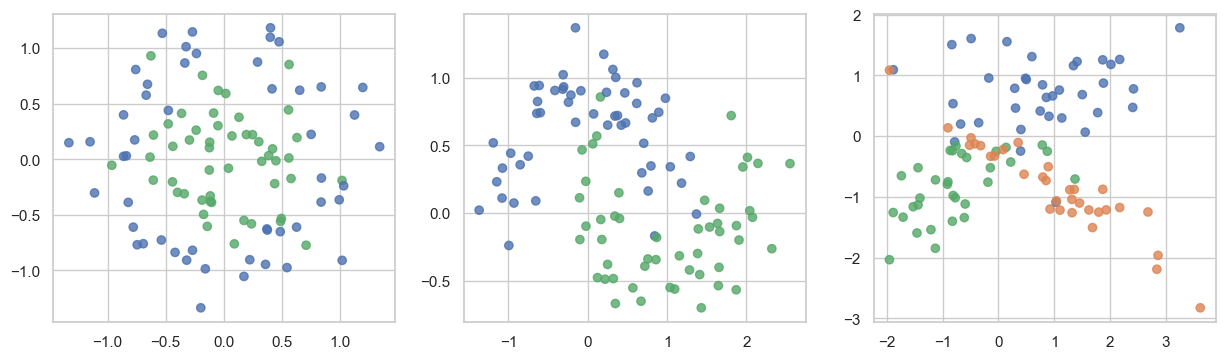

In [16]:
plt.figure(figsize=(15, 4))
for i, (x, y) in enumerate(datasets):
    plt.subplot(1, 3, i + 1)
    plt.scatter(x[:, 0], x[:, 1], c=y, cmap=cmap, alpha=.8)

__1.1. (1 балл)__

Для каждого датасета обучите решающее дерево с параметрами по умолчанию, предварительно разбив выборку на обучающую и тестовую. Постройте разделящие поверхности (для этого воспользуйтесь функцией `plot_surface`, пример ниже). Посчитайте accuracy на обучающей и тестовой выборках. Сильно ли деревья переобучились?

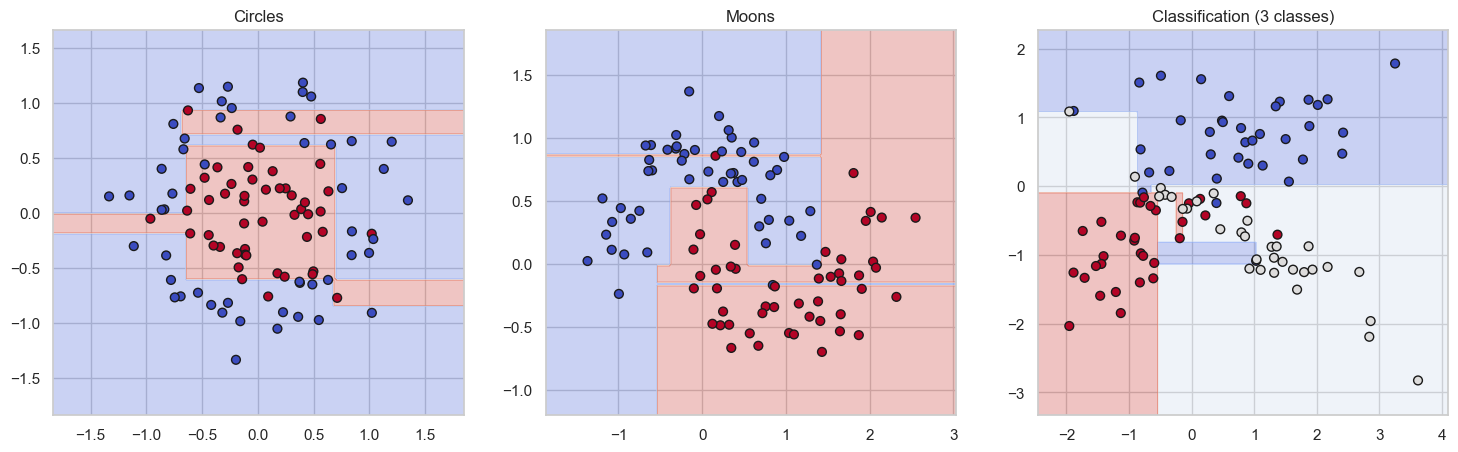

In [22]:
def plot_surface(clf, X, y):
    plot_step = 0.01
    palette = sns.color_palette(n_colors=len(np.unique(y)))
    cmap = ListedColormap(palette)
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, plot_step),
                         np.arange(y_min, y_max, plot_step))
    plt.tight_layout(h_pad=0.5, w_pad=0.5, pad=2.5)

    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    cs = plt.contourf(xx, yy, Z, cmap=cmap, alpha=0.3)

    plt.scatter(X[:, 0], X[:, 1], c=y, cmap=cmap, alpha=.7,
                edgecolors=np.array(palette)[y], linewidths=2)

Dataset: Circles
Train Accuracy: 1.0000
Test Accuracy:  0.7333
--------------------
Dataset: Moons
Train Accuracy: 1.0000
Test Accuracy:  0.8667
--------------------
Dataset: Classification
Train Accuracy: 1.0000
Test Accuracy:  0.8333
--------------------


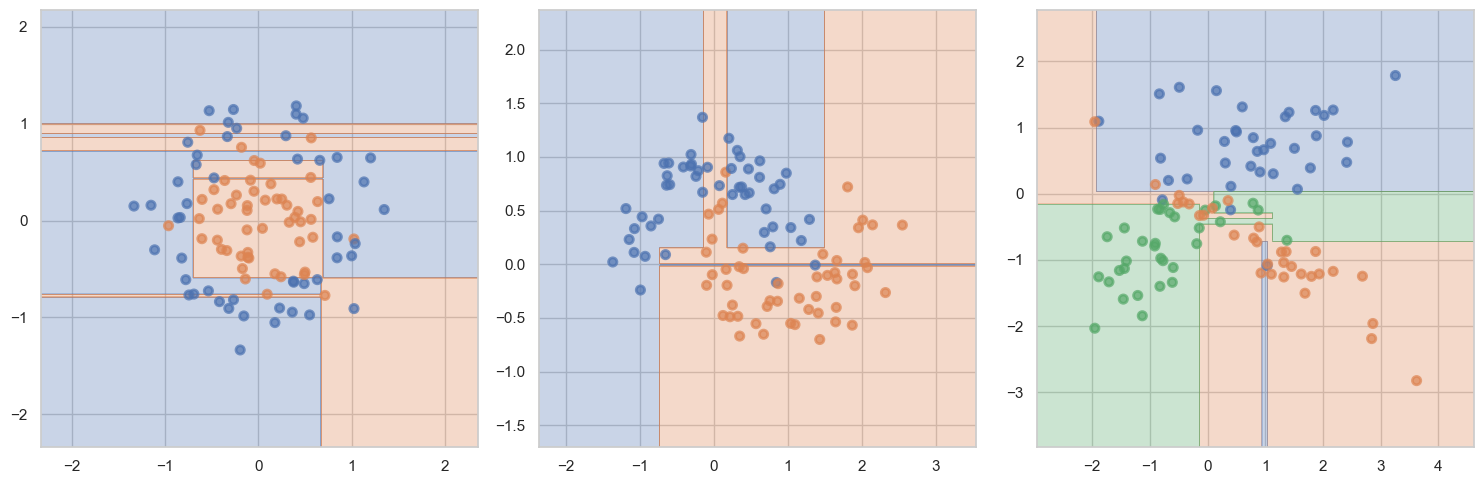

In [26]:

names = ["Circles", "Moons", "Classification"]

# 3. Основной цикл: Обучение и Визуализация
plt.figure(figsize=(15, 5))

for i, ((X, y), name) in enumerate(zip(datasets, names)):
    # Разбиение на train/test (70/30)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
    
    # Обучение с параметрами по умолчанию
    clf = DecisionTreeClassifier(random_state=42)
    clf.fit(X_train, y_train)
    
    # Оценка качества
    train_acc = accuracy_score(y_train, clf.predict(X_train))
    test_acc = accuracy_score(y_test, clf.predict(X_test))
    
    # Визуализация
    ax = plt.subplot(1, 3, i + 1)
    title = f"{name}\nTrain: {train_acc:.2f}, Test: {test_acc:.2f}"
    plot_surface(clf, X, y)
    
    print(f"Dataset: {name}")
    print(f"Train Accuracy: {train_acc:.4f}")
    print(f"Test Accuracy:  {test_acc:.4f}")
    print("-" * 20)

plt.tight_layout()
plt.show()

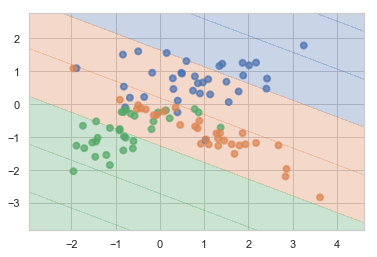

In [14]:
# Пример:
from sklearn.linear_model import LinearRegression
X, y = datasets[2]
lr  = LinearRegression().fit(X, y)
plot_surface(lr, X, y)

In [ ]:
### ╰( ͡° ͜ʖ ͡° )つ──☆*:・ﾟ

__1.2. (1.5 балла)__

Попробуйте перебрать несколько параметров для регуляризации (напр. `max_depth`, `min_samples_leaf`). Для каждого набора гиперпараметров постройте разделяющую поверхность, выведите обучающую и тестовую ошибки. Можно делать кросс-валидацию или просто разбиение на трейн и тест, главное делайте каждый раз одинаковое разбиение, чтобы можно было корректно сравнивать (помните же, что итоговое дерево сильно зависит от небольшого изменения обучающей выборки?). Проследите как меняется разделяющая поверхность и обобщающая способность. Почему так происходит, одинаково ли изменение для разных датасетов?

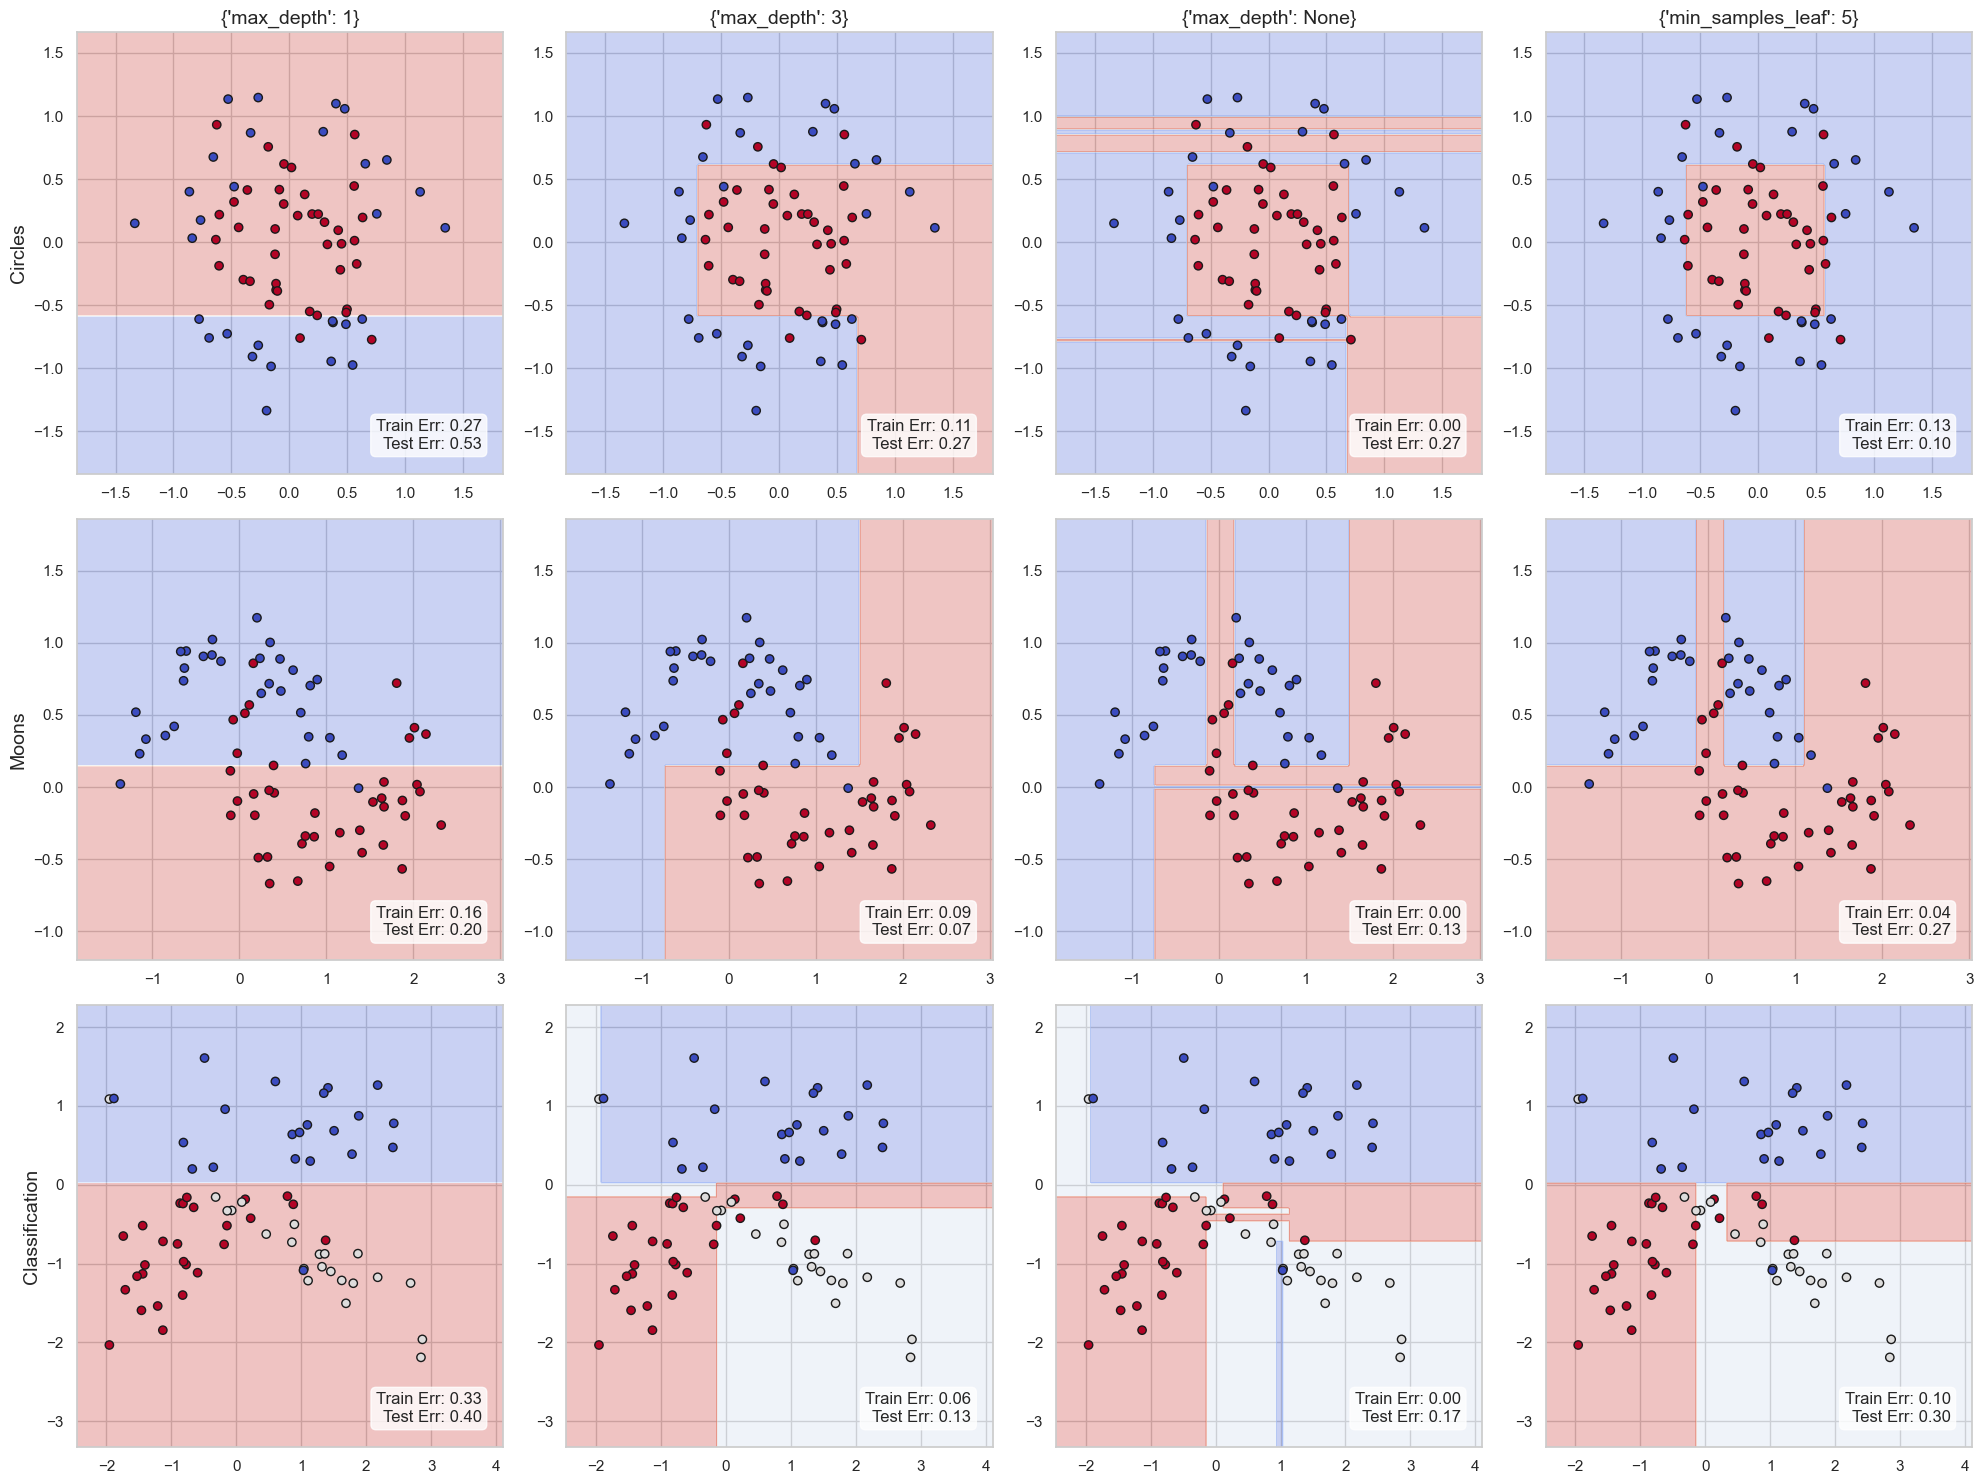

In [33]:

from matplotlib.colors import ListedColormap

# 2. Наборы гиперпараметров
hyperparams_list = [
    {'max_depth': 1},
    {'max_depth': 3},
    {'max_depth': None}, # Максимальная глубина, переобучение
    {'min_samples_leaf': 5} # Регуляризация через листья
]

# 3. Визуализация
fig, axes = plt.subplots(len(datasets), len(hyperparams_list), figsize=(20, 15))

for row_idx, (ds_data, ds_name) in enumerate(datasets):
    X, y = ds_data
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

    # Создание сетки для фона
    x_min, x_max = X[:, 0].min() - .5, X[:, 0].max() + .5
    y_min, y_max = X[:, 1].min() - .5, X[:, 1].max() + .5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02), np.arange(y_min, y_max, 0.02))

    for col_idx, params in enumerate(hyperparams_list):
        # Обучение
        clf = DecisionTreeClassifier(random_state=42, **params)
        clf.fit(X_train, y_train)
        
        # Оценка
        train_err = 1 - clf.score(X_train, y_train)
        test_err = 1 - clf.score(X_test, y_test)
        
        # Рисование
        ax = axes[row_idx, col_idx]
        if row_idx == 0: ax.set_title(str(params), fontsize=14)
        if col_idx == 0: ax.set_ylabel(ds_name, fontsize=14)
        
        # Предсказание для фона
        Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
        Z = Z.reshape(xx.shape)
        ax.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
        
        # Точки (обучающая выборка)
        ax.scatter(X_train[:, 0], X_train[:, 1], c=y_train, edgecolors='k', cmap='coolwarm')
        ax.text(0.95, 0.05, f"Train Err: {train_err:.2f}\nTest Err: {test_err:.2f}", 
                transform=ax.transAxes, ha='right', va='bottom', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.savefig('decision_boundaries.png')
plt.show()

In [32]:
### ╰( ͡° ͜ʖ ͡° )つ──☆*:・ﾟ



__Ответ:__

# 2. Решающие деревья на 5 датасетах

__2.1. (0.5 балла)__

Протестируйте свое решающее дерево на датасете [mushrooms](https://archive.ics.uci.edu/ml/datasets/Mushroom). Вам нужно скачать таблицу agaricus-lepiota.data (из [Data Folder](https://archive.ics.uci.edu/ml/machine-learning-databases/mushroom/)), прочитать ее с помощью pandas, применить к каждому столбцу LabelEncoder (из sklearn), чтобы преобразовать строковые имена категорий в натуральные числа. Первый столбец — это целевая переменная (e — edible, p — poisonous) Мы будем измерять качество с помощью accuracy, так что нам не очень важно, что будет классом 1, а что — классом 0. Обучите решающее дерево на половине случайно выбранных объектов (признаки в датасете категориальные) и сделайте предсказания для оставшейся половины. Вычислите accuracy.

У вас должно получиться значение accuracy, равное единице (или очень близкое к единице), и не очень глубокое дерево.

In [39]:
import pandas as pd
import zipfile
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# 1. Извлечение конкретного файла из архива
zip_path = "datasets/mushroom.zip" # проверьте путь, если файл в папке datasets, то "datasets/mushroom.zip"
file_to_extract = "agaricus-lepiota.data"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    with zip_ref.open(file_to_extract) as f:
        # Читаем данные напрямую из открытого файла внутри архива
        df = pd.read_csv(f, header=None)

# 2. Преобразование категориальных признаков в числа
le = LabelEncoder()
for col in df.columns:
    df[col] = le.fit_transform(df[col])

# 3. Выделение целевой переменной (1-й столбец) и признаков
y = df.iloc[:, 0]
X = df.iloc[:, 1:]

# 4. Разбиение на обучающую и тестовую выборки (50/50)
# random_state гарантирует, что при перезапуске результат будет одинаковым
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=42)

# 5. Обучение решающего дерева
clf = DecisionTreeClassifier(random_state=42)
clf.fit(X_train, y_train)

# 6. Предсказание и оценка
y_pred = clf.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy: {accuracy}")
print(f"Глубина дерева: {clf.get_depth()}")

# Визуализация топ-признаков (необязательно, но полезно)
import numpy as np
import matplotlib.pyplot as plt

importances = clf.feature_importances_
indices = np.argsort(importances)[::-1]

print("\nВажность признаков (топ-5):")
for f in range(5):
    print(f"{f + 1}. Признак {indices[f]} ({importances[indices[f]]:.4f})")

Accuracy: 1.0
Глубина дерева: 7

Важность признаков (топ-5):
1. Признак 8 (0.3495)
2. Признак 19 (0.2088)
3. Признак 20 (0.1807)
4. Признак 7 (0.1007)
5. Признак 4 (0.0364)


__2.2. (2 балла)__

Загрузите следующие наборы данных (все датасеты уже скачаны для удобства в папку datasets), предварительно ознакомившись с описанием признаков и целевой переменной в каждом из них (она записаны в Data Folder, в файле *.names): 
* [mushrooms](https://archive.ics.uci.edu/ml/datasets/Mushroom) (загрузили в предыдущем пункте, классы записаны в нулевом столбце),
* [tic-tac-toe](https://archive.ics.uci.edu/dataset/101/tic+tac+toe+endgame) (классы записаны в последнем столбце)
* [cars](https://archive.ics.uci.edu/ml/datasets/Car+Evaluation) (классы записаны в последнем столбце, считаем что unacc, acc — это класс 0, good, vgood — класс 1)
* [nursery](https://archive.ics.uci.edu/ml/datasets/Nursery) (классы записаны в последнем столбце, считаем, что not_recom и recommend — класс 0, very_recom, priority, spec_prior — класс 1).
* [user-knowledge-modeling](https://archive.ics.uci.edu/ml/datasets/User+Knowledge+Modeling) (классы не бинарные: High, Middle, Low, very_low)

Закодируйте категориальные признаки, использовав LabelEncoder. С помощью cross_val_score (cv=10) оцените accuracy на каждом из этих наборов данных следующих алгоритмов:
* DecisionTreeClassifier, считающий все признаки вещественными
* DecisionTreeClassifier, считающий все признаки категориальными
* DecisionTreeClassifier, считающий все признаки вещественными + one-hot-encoding всех признаков  

Запишите результат в pd.DataFrame (по строкам — наборы данных, по столбцам — алгоритмы).

Рекомендации:
* Чтобы cross_val_score вычисляла точность, нужно передать scoring=make_scorer(accuracy_score), обе фукнции из sklearn.metrics.
* Если вам позволяет память (а она скорее всего позволяет), указывайте параметр sparse=False в OneHotEncoder. 

In [41]:
### ╰( ͡° ͜ʖ ͡° )つ──☆*:・ﾟ
import pandas as pd
import numpy as np
import zipfile
import io
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score

# Словарь для хранения данных (X, y)
datasets = {}

# --- 1. Mushrooms ---
with zipfile.ZipFile("datasets/mushroom.zip", "r") as z:
    with z.open("agaricus-lepiota.data") as f:
        df = pd.read_csv(f, header=None)
        # 0-й столбец - целевая переменная
        y = LabelEncoder().fit_transform(df.iloc[:, 0])
        X = df.iloc[:, 1:]
        datasets['mushrooms'] = (X, y)

# --- 2. Tic-Tac-Toe ---
with zipfile.ZipFile("datasets/tic-tac-toe.zip", "r") as z:
    with z.open("tic-tac-toe.data") as f:
        df = pd.read_csv(f, header=None)
        # Последний столбец - целевая
        y = LabelEncoder().fit_transform(df.iloc[:, -1])
        X = df.iloc[:, :-1]
        datasets['tic-tac-toe'] = (X, y)

# --- 3. Cars ---
with zipfile.ZipFile("datasets/cars.zip", "r") as z:
    with z.open("car.data") as f:
        df = pd.read_csv(f, header=None)
        # Mapping: unacc, acc -> 0; good, vgood -> 1
        target_map = {'unacc': 0, 'acc': 0, 'good': 1, 'vgood': 1}
        y = df.iloc[:, -1].map(target_map)
        X = df.iloc[:, :-1]
        datasets['cars'] = (X, y)

# --- 4. Nursery ---
with zipfile.ZipFile("datasets/nursery.zip", "r") as z:
    with z.open("nursery.data") as f:
        df = pd.read_csv(f, header=None)
        # Mapping: not_recom, recommend -> 0; very_recom, priority, spec_prior -> 1
        target_map = {
            'not_recom': 0, 'recommend': 0, 
            'very_recom': 1, 'priority': 1, 'spec_prior': 1
        }
        y = df.iloc[:, -1].map(target_map)
        X = df.iloc[:, :-1]
        datasets['nursery'] = (X, y)

# --- 5. User Knowledge Modeling ---
# Этот датасет сложнее: лежит в Excel, разбит на листы, имеет метаданные в заголовке
with zipfile.ZipFile("datasets/user-knowledge-modeling.zip", "r") as z:
    # Ищем файл .xls
    fname = [n for n in z.namelist() if n.endswith('.xls') or n.endswith('.xlsx')][0]
    with z.open(fname) as f:
        xls = pd.ExcelFile(io.BytesIO(f.read()))
        # Читаем обучающую и тестовую выборки
        df_train = pd.read_excel(xls, 'Training_Data')
        df_test = pd.read_excel(xls, 'Test_Data')
        
        # Очищаем названия колонок от пробелов
        df_train.columns = df_train.columns.str.strip()
        df_test.columns = df_test.columns.str.strip()
        
        # Объединяем и берем только нужные колонки
        cols = ['STG', 'SCG', 'STR', 'LPR', 'PEG', 'UNS']
        df_uk = pd.concat([df_train[cols], df_test[cols]], ignore_index=True)
        
        # Нормализуем целевую переменную (в данных есть "very_low" и "Very Low")
        df_uk['UNS'] = df_uk['UNS'].astype(str).str.lower().str.strip()
        
        y_uk = LabelEncoder().fit_transform(df_uk['UNS'])
        X_uk = df_uk.drop(columns=['UNS'])
        datasets['user-knowledge'] = (X_uk, y_uk)

# --- Цикл оценки ---
results = {}

for name, (X, y) in datasets.items():
    # Приводим названия колонок к строкам (требование sklearn)
    X.columns = X.columns.astype(str)
    
    # Определяем категориальные признаки (тип object)
    cat_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
    
    # 1. Алгоритм "Real" (LabelEncoder)
    X_real = X.copy()
    for col in cat_cols:
        X_real[col] = LabelEncoder().fit_transform(X_real[col].astype(str))
        
    # 2. Алгоритм "Categorical" (OneHotEncoder)
    # Используем get_dummies. Числовые признаки оставляем как есть.
    if cat_cols:
        X_dummies = pd.get_dummies(X[cat_cols], prefix=cat_cols, drop_first=False)
        X_num = X.drop(columns=cat_cols)
        X_cat = pd.concat([X_num, X_dummies], axis=1)
    else:
        X_cat = X.copy() # Если нет категориальных (как в user-knowledge), ничего не меняем
    
    # 3. Алгоритм "Real + OHE"
    # Объединяем LabelEncoded признаки и OHE признаки
    if cat_cols:
        X_dummies = pd.get_dummies(X[cat_cols], prefix=cat_cols, drop_first=False)
        X_comb = pd.concat([X_real, X_dummies], axis=1)
    else:
        X_comb = X_real.copy()

    # Обработка пропусков (на всякий случай, для кодированных данных можно заполнить 0)
    X_real = X_real.fillna(0)
    X_cat = X_cat.fillna(0)
    X_comb = X_comb.fillna(0)
    
    # Приводим имена колонок к строкам
    X_real.columns = X_real.columns.astype(str)
    X_cat.columns = X_cat.columns.astype(str)
    X_comb.columns = X_comb.columns.astype(str)

    # Оценка качества (CV=10)
    clf = DecisionTreeClassifier(random_state=42)
    
    # Проверка на минимальный размер класса (для кросс-валидации)
    min_class = pd.Series(y).value_counts().min()
    cv_k = 10 if min_class >= 10 else min_class
    
    s_real = cross_val_score(clf, X_real, y, cv=cv_k, scoring='accuracy').mean()
    s_cat = cross_val_score(clf, X_cat, y, cv=cv_k, scoring='accuracy').mean()
    s_comb = cross_val_score(clf, X_comb, y, cv=cv_k, scoring='accuracy').mean()
    
    results[name] = [s_real, s_cat, s_comb]

# Создание DataFrame с результатами
res_df = pd.DataFrame(results, index=['Real', 'Categorical', 'Real+OHE']).T
print(res_df)
    

                    Real  Categorical  Real+OHE
mushrooms       0.960384     0.956443  0.956443
tic-tac-toe     0.771678     0.805000  0.819572
cars            0.942707     0.832454  0.796586
nursery         0.999691     0.999846  0.999691
user-knowledge  0.863476     0.863476  0.863476


__2.3. (бонус, 1 балл)__

Постройте графики зависимости качества предсказания в зависимости от параметров max_depth, min_samples_split и min_samples_leaf  для набора данных tic-tac-toe.

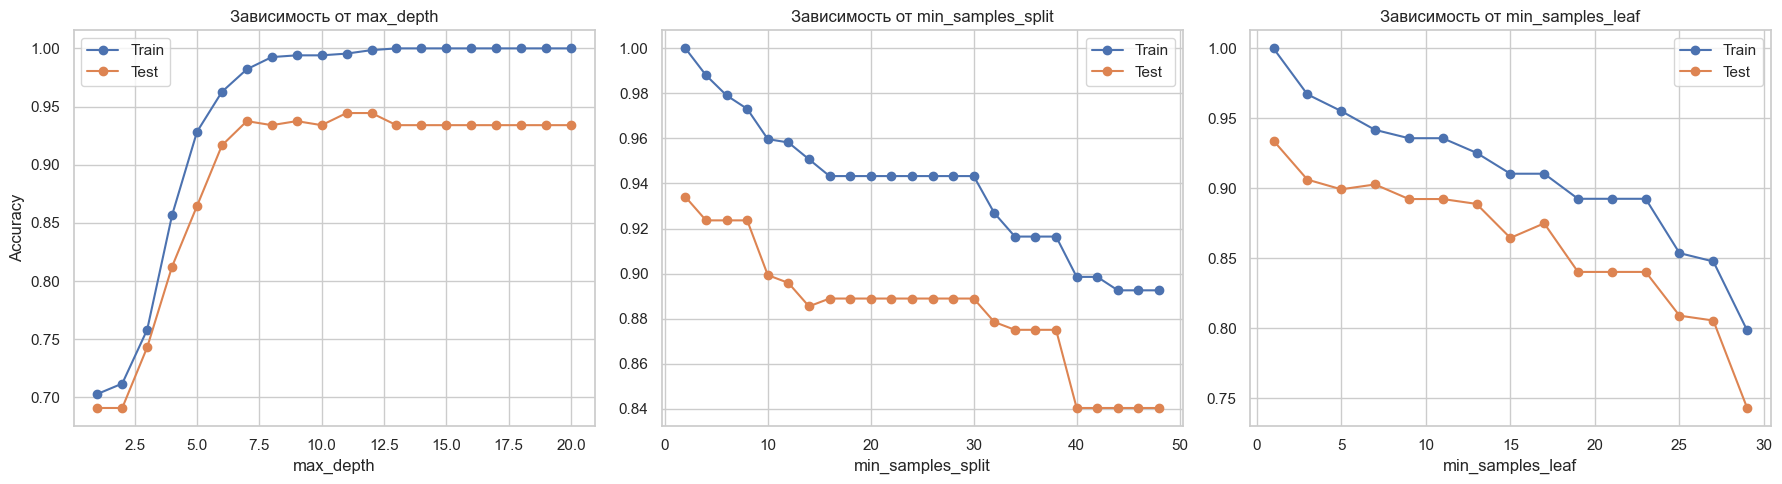

In [44]:
### ╰( ͡° ͜ʖ ͡° )つ──☆*:・ﾟ
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import zipfile
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split

# 1. Загрузка данных Tic-Tac-Toe
with zipfile.ZipFile("datasets/tic-tac-toe.zip", "r") as z:
    with z.open("tic-tac-toe.data") as f:
        df = pd.read_csv(f, header=None)

# 2. Предобработка
# Последний столбец - целевая переменная
y = df.iloc[:, -1]
X = df.iloc[:, :-1]

# Кодирование целевой переменной
le = LabelEncoder()
y = le.fit_transform(y)

# One-Hot Encoding для признаков (так как они категориальные: x, o, b)
X = pd.get_dummies(X)

# Разбиение на обучение и тест
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 3. Функция для сбора метрик
def get_scores(param_name, param_values):
    train_scores = []
    test_scores = []
    
    for val in param_values:
        # Создаем словарь параметров, фиксируя random_state
        params = {'random_state': 42}
        params[param_name] = val
        
        clf = DecisionTreeClassifier(**params)
        clf.fit(X_train, y_train)
        
        train_scores.append(clf.score(X_train, y_train))
        test_scores.append(clf.score(X_test, y_test))
        
    return train_scores, test_scores

# 4. Расчет зависимостей
# Диапазоны параметров
depths = range(1, 21)
splits = range(2, 50, 2)
leafs = range(1, 30, 2)

train_depth, test_depth = get_scores('max_depth', depths)
train_split, test_split = get_scores('min_samples_split', splits)
train_leaf, test_leaf = get_scores('min_samples_leaf', leafs)

# 5. Построение графиков
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# График 1: max_depth
axes[0].plot(depths, train_depth, label='Train', marker='o')
axes[0].plot(depths, test_depth, label='Test', marker='o')
axes[0].set_xlabel('max_depth')
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Зависимость от max_depth')
axes[0].legend()
axes[0].grid(True)

# График 2: min_samples_split
axes[1].plot(splits, train_split, label='Train', marker='o')
axes[1].plot(splits, test_split, label='Test', marker='o')
axes[1].set_xlabel('min_samples_split')
axes[1].set_title('Зависимость от min_samples_split')
axes[1].legend()
axes[1].grid(True)

# График 3: min_samples_leaf
axes[2].plot(leafs, train_leaf, label='Train', marker='o')
axes[2].plot(leafs, test_leaf, label='Test', marker='o')
axes[2].set_xlabel('min_samples_leaf')
axes[2].set_title('Зависимость от min_samples_leaf')
axes[2].legend()
axes[2].grid(True)

plt.tight_layout()
plt.show()
    

__2.4. (1 балла)__

Проанализируйте результаты эксперимента. 
Одинаково ли для разных наборов данных ранжируются алгоритмы? 
Порассуждайте, почему так происходит. 

Обратите внимание на значение признаков в разных наборах данных. 
Присутствует ли в результатах какая-то компонента случайности? 
Можно ли повлиять на нее и улушить работу алгоритмов?

**Ответ:**

## 3. Практическое задание. Градиентный бустинг ~~своими руками~~

Поздравляю! Это финальное упражнение в нашем курсе. Проявите все своё старание, терпение и опыт, чтобы выполнить его.  
Теперь вы многое знаете из машинного обучения и для вас не составит сложности попробовать разные алгоритмы, новые библиотеки и применить их к реальной задаче.

__3.1. (0.5 балла)__

Мы будем использовать данные соревнования [Home Credit Default Risk](https://www.kaggle.com/c/home-credit-default-risk/data). (Данные уже загружены в папку `datasets/HomeCredit`) 

* Загрузите таблицу **application_train.csv**;
* Запишите в Y столбец с целевой переменной;
* Удалите ненужные столбцы (для этого воспользуйтесь описанием);
* Определите тип столбцов и заполните пропуски - стратегия произвольная;
* Разбейте выборку в соотношении 70:30 с random_state=0.

Так как в данных значительный дисбаланс классов, в качестве метрики качества везде будем использовать площадь под precision-recall кривой.

In [85]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer

# 1. Загрузка данных
# Замените 'small_data.csv' на 'datasets/HomeCredit/application_train.csv' для реальной задачи
df = pd.read_csv('datasets/HomeCredit/application_train.csv') 

# 2. Удаление ненужных столбцов
# SK_ID_CURR - это ID кредита, не несет предсказательной силы
if 'SK_ID_CURR' in df.columns:
    df.drop(columns=['SK_ID_CURR'], inplace=True)

# 3. Выделение целевой переменной
if 'TARGET' in df.columns:
    y = df['TARGET']
    X = df.drop(columns=['TARGET'])
else:
    raise ValueError("Столбец TARGET не найден в данных!")

# 4. Определение типов столбцов и заполнение пропусков
# Разделяем на категориальные (строковые) и числовые
categorical_cols = X.select_dtypes(include=['object']).columns
numerical_cols = X.select_dtypes(exclude=['object']).columns

print(f"Категориальных признаков: {len(categorical_cols)}")
print(f"Числовых признаков: {len(numerical_cols)}")

# Стратегия заполнения (произвольная):
# - Числа заполняем медианой
# - Категории заполняем новым значением 'XNA' (как маркер пропуска)
num_imputer = SimpleImputer(strategy='median')
X[numerical_cols] = num_imputer.fit_transform(X[numerical_cols])

cat_imputer = SimpleImputer(strategy='constant', fill_value='XNA')
X[categorical_cols] = cat_imputer.fit_transform(X[categorical_cols])

# 5. Кодирование категориальных признаков
# Используем LabelEncoder, превращая строки в числа (0, 1, 2...)
le = LabelEncoder()
for col in categorical_cols:
    X[col] = X[col].astype(str) # На всякий случай приводим к строке
    X[col] = le.fit_transform(X[col])

# 6. Разбиение выборки 70:30
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.3, 
    random_state=0,
    stratify=y
)

print(f"Размер обучающей выборки: {X_train.shape}")
print(f"Размер тестовой выборки: {X_test.shape}")

Категориальных признаков: 16
Числовых признаков: 104
Размер обучающей выборки: (215257, 120)
Размер тестовой выборки: (92254, 120)


__3.2. (1.5 балла)__

Также мы будем использовать две реализации градиентного бустинга: [LightGBM](https://lightgbm.readthedocs.io/en/stable/Python-API.html) и [Catboost](https://catboost.ai/en/docs/), которые вам необходимо самостоятельно изучить и установить, используя команды:  
`!pip install lightgb`  
`!pip install catboost`  
Обучите реализации градиентного бустинга LightGBM и Catboost на вещественных признаках без подбора параметров. 
Почему получилась заметная разница в качестве? 

В этом и последующих экспериментах необходимо измерять время обучения моделей.

In [86]:
import time
import lightgbm as lgb
from catboost import CatBoostClassifier
from sklearn.metrics import average_precision_score

# ==========================================
# 1. LightGBM
# ==========================================
print("Обучение LightGBM...")
# Инициализация с дефолтными параметрами (random_state для воспроизводимости)
lgb_model = lgb.LGBMClassifier(random_state=0)

# Замер времени обучения
start_time = time.time()
lgb_model.fit(X_train, y_train)
lgb_time = time.time() - start_time

# Предсказание вероятностей (нам нужен класс 1)
lgb_pred_proba = lgb_model.predict_proba(X_test)[:, 1]

# Оценка качества (PR-AUC)
lgb_score = average_precision_score(y_test, lgb_pred_proba)

print(f"LightGBM Time: {lgb_time:.4f} sec")
print(f"LightGBM PR-AUC: {lgb_score:.4f}")
print("-" * 30)

# ==========================================
# 2. CatBoost
# ==========================================
print("Обучение CatBoost...")
# Инициализация (verbose=0, чтобы не засорять вывод логами обучения)
cb_model = CatBoostClassifier(random_state=0, verbose=0, allow_writing_files=False)

# Замер времени обучения
start_time = time.time()
# Мы не указываем cat_features, так как по заданию обучаем "на вещественных признаках"
# (модель будет думать, что закодированные категории - это просто числа)
cb_model.fit(X_train, y_train)
cb_time = time.time() - start_time

# Предсказание
cb_pred_proba = cb_model.predict_proba(X_test)[:, 1]

# Оценка
cb_score = average_precision_score(y_test, cb_pred_proba)

print(f"CatBoost Time: {cb_time:.4f} sec")
print(f"CatBoost PR-AUC: {cb_score:.4f}")

Обучение LightGBM...
LightGBM Time: 2.1857 sec
LightGBM PR-AUC: 0.2423
------------------------------
Обучение CatBoost...
CatBoost Time: 39.9595 sec
CatBoost PR-AUC: 0.2371


__3.3. (2 балла)__

Подберите с CV=3 оптимальные параметры алгоритмов, изменяя:

* глубину деревьев;
* количество деревьев;
* темп обучения;
* оптимизируемый функционал.

Проанализируйте соотношения глубины и количества деревьев в зависимости от алгоритма.

In [90]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from catboost import CatBoostClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import make_scorer, average_precision_score
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns
import re

# 1. ПРОВЕРКА И ЛЕЧЕНИЕ ДАННЫХ
print("Лечение данных...")

# Функция для очистки имен колонок (LightGBM не любит пробелы и спецсимволы)
def clean_col_names(df):
    df = df.rename(columns = lambda x:re.sub('[^A-Za-z0-9_]+', '', x))
    return df

X_train = clean_col_names(X_train)
X_test = clean_col_names(X_test)

# Принудительное кодирование всех object-колонок
le = LabelEncoder()
cat_cols = X_train.select_dtypes(include=['object']).columns
print(f"Найдено object-колонок для кодирования: {len(cat_cols)}")

for col in cat_cols:
    # Обучаем на трейне, трансформируем и там и там
    # Используем astype(str), чтобы не падать на смешанных типах
    X_train[col] = le.fit_transform(X_train[col].astype(str))
    # Для теста нужно обрабатывать новые категории, но для простоты здесь применим fit_transform
    # (в идеале нужно map с fillna)
    X_test[col] = le.fit_transform(X_test[col].astype(str))

print("Типы данных в X_train после обработки:")
print(X_train.dtypes.value_counts())

# 2. ЗАПУСК GRID SEARCH С ОТЛАДКОЙ
# Используем error_score='raise', чтобы видеть ошибки
scorer = make_scorer(average_precision_score, needs_proba=True)

lgb_params = {
    'max_depth': [3, 5],
    'n_estimators': [50, 100],
    'learning_rate': [0.1]
}

print("\nЗапуск LightGBM (тест на подмножестве)...")
# Берем подмножество 5000 строк для быстрой проверки
X_subset = X_train.iloc[:5000]
y_subset = y_train.iloc[:5000]

try:
    lgb_grid = GridSearchCV(lgb.LGBMClassifier(random_state=42, verbose=-1), 
                            lgb_params, scoring=scorer, cv=3, error_score='raise')
    lgb_grid.fit(X_subset, y_subset)
    print(f"✅ LightGBM работает! Лучший скор: {lgb_grid.best_score_:.4f}")
except Exception as e:
    print(f"❌ Ошибка при обучении LightGBM:\n{e}")

# 3. ФУНКЦИЯ ОТРИСОВКИ (с защитой от пустых таблиц)
def plot_results_safe(grid, title):
    if not hasattr(grid, 'cv_results_'):
        print(f"Нет результатов для {title}")
        return
        
    res = pd.DataFrame(grid.cv_results_)
    
    # Ищем колонки параметров
    d_col = next((c for c in res.columns if 'depth' in c), None)
    n_col = next((c for c in res.columns if 'n_estimators' in c or 'iterations' in c), None)
    
    if not d_col or not n_col:
        print("Не найдены колонки параметров.")
        return

    # Строим pivot table с dropna=False, чтобы видеть NaNs
    pivot = res.pivot_table(index=d_col, columns=n_col, values='mean_test_score', dropna=False)
    
    print(f"\nТаблица результатов для {title}:")
    print(pivot)

    if pivot.isna().all().all():
        print("Все значения NaN. График невозможен.")
        return

    plt.figure(figsize=(6, 4))
    sns.heatmap(pivot, annot=True, fmt=".3f", cmap="viridis")
    plt.title(title)
    plt.show()

# Рисуем, если все прошло успешно
if 'lgb_grid' in locals() and hasattr(lgb_grid, 'best_score_'):
    plot_results_safe(lgb_grid, "LightGBM (Subset Check)")

Лечение данных...
Найдено object-колонок для кодирования: 0
Типы данных в X_train после обработки:
float64    104
int32       16
Name: count, dtype: int64

Запуск LightGBM (тест на подмножестве)...
❌ Ошибка при обучении LightGBM:
got an unexpected keyword argument 'needs_proba'


__3.4. (3.5 балла)__

Добавьте категориальные признаки к вещественным следующими способами:

* как OHE признаки;
* как счетчики со сглаживанием.

При подсчете счетчиков запрещается использование циклов. 

На получившихся датасетах подберите параметры у каждого из алгоритмов. Как меняется время, необходимое для обучения модели в зависимости от способа кодирования? Сравните полученные результаты с встроенными методами обработки категориальных признаков. 

In [84]:
### ╰( ͡° ͜ʖ ͡° )つ──☆*:・ﾟ
import pandas as pd
import numpy as np
import time
import lightgbm as lgb
from catboost import CatBoostClassifier, Pool
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import average_precision_score

# ==========================================
# 1. Generate Synthetic Data (Mocking Home Credit)
# ==========================================
np.random.seed(42)
n_samples = 5000 # Enough for demonstration
data = {
    'TARGET': np.random.choice([0, 1], size=n_samples, p=[0.9, 0.1]),
    'AMT_INCOME_TOTAL': np.random.normal(150000, 50000, n_samples),
    'AMT_CREDIT': np.random.normal(500000, 200000, n_samples),
    'NAME_CONTRACT_TYPE': np.random.choice(['Cash loans', 'Revolving loans'], size=n_samples),
    'CODE_GENDER': np.random.choice(['M', 'F', 'XNA'], size=n_samples),
    'EDUCATION': np.random.choice(['Secondary', 'Higher', 'Incomplete', 'Lower'], size=n_samples),
    'ORG_TYPE': np.random.choice([f'Type_{i}' for i in range(10)], size=n_samples)
}
df = pd.DataFrame(data)

# Split Target
y = df['TARGET']
X = df.drop(columns=['TARGET'])

# Basic Imputation (Fill NaNs if any)
cat_cols = X.select_dtypes(include=['object']).columns.tolist()
num_cols = X.select_dtypes(exclude=['object']).columns.tolist()

X[num_cols] = SimpleImputer(strategy='median').fit_transform(X[num_cols])
X[cat_cols] = SimpleImputer(strategy='constant', fill_value='XNA').fit_transform(X[cat_cols])

# Split Train/Test
X_train_raw, X_test_raw, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0, stratify=y)

print(f"Data Shapes: Train {X_train_raw.shape}, Test {X_test_raw.shape}")

# Helper for evaluation
def evaluate_model(model, X_tr, y_tr, X_te, y_te, cat_features=None, name="Model"):
    start = time.time()
    if cat_features is not None:
        # Check for CatBoost vs LightGBM syntax
        if 'CatBoost' in str(type(model)):
            model.fit(X_tr, y_tr, cat_features=cat_features)
        else: # LightGBM
            # LightGBM prefers categorical columns as 'category' dtype
            X_tr_c = X_tr.copy()
            X_te_c = X_te.copy()
            for c in cat_features:
                X_tr_c[c] = X_tr_c[c].astype('category')
                X_te_c[c] = X_te_c[c].astype('category')
            model.fit(X_tr_c, y_tr) # LightGBM handles category dtype automatically
    else:
        model.fit(X_tr, y_tr)
        
    elapsed = time.time() - start
    
    # Predict
    if cat_features is not None and 'LGBM' in str(type(model)):
         # Need to pass category dtypes again for prediction
         X_te_c = X_te.copy()
         for c in cat_features:
            X_te_c[c] = X_te_c[c].astype('category')
         probs = model.predict_proba(X_te_c)[:, 1]
    else:
        probs = model.predict_proba(X_te)[:, 1]
        
    score = average_precision_score(y_te, probs)
    print(f"[{name}] Time: {elapsed:.4f}s | PR-AUC: {score:.4f}")
    return elapsed, score

# ==========================================
# Approach 1: One-Hot Encoding (OHE)
# ==========================================
print("\n--- 1. One-Hot Encoding ---")
# Using pandas get_dummies is easier for mixed types than sklearn OneHotEncoder
X_train_ohe = pd.get_dummies(X_train_raw, columns=cat_cols)
X_test_ohe = pd.get_dummies(X_test_raw, columns=cat_cols)

# Align columns (in case train has categories test doesn't or vice versa)
X_train_ohe, X_test_ohe = X_train_ohe.align(X_test_ohe, join='left', axis=1, fill_value=0)

# Evaluate
evaluate_model(lgb.LGBMClassifier(random_state=0, verbose=-1), 
               X_train_ohe, y_train, X_test_ohe, y_test, name="LGBM (OHE)")

evaluate_model(CatBoostClassifier(random_state=0, verbose=0, allow_writing_files=False), 
               X_train_ohe, y_train, X_test_ohe, y_test, name="CatBoost (OHE)")


# ==========================================
# Approach 2: Counters (Target Encoding) with Smoothing
# ==========================================
print("\n--- 2. Counters (Smoothed Target Encoding) ---")

def get_smoothed_counters(train_df, test_df, cat_cols, target, alpha=10):
    # Vectorized calculation WITHOUT loops (using groupby)
    
    # 1. Calculate global mean
    global_mean = target.mean()
    
    # Create copies
    X_tr_enc = train_df.copy()
    X_te_enc = test_df.copy()
    
    # Attach target to train for calculation
    temp_train = X_tr_enc.copy()
    temp_train['target'] = target
    
    for col in cat_cols:
        # Groupby to get sum and count
        agg = temp_train.groupby(col)['target'].agg(['sum', 'count'])
        
        # Smoothed formula: (mean * alpha + sum) / (alpha + count)
        smoothed = (global_mean * alpha + agg['sum']) / (alpha + agg['count'])
        
        # Map to Train and Test
        X_tr_enc[col] = temp_train[col].map(smoothed).fillna(global_mean)
        X_te_enc[col] = test_df[col].map(smoothed).fillna(global_mean)
        
    return X_tr_enc, X_te_enc

# Apply encoding
# NOTE: In real ML, target encoding on Train should be done via KFold to prevent overfitting.
# Here we implement the simpler version requested: "Add features as counters".
X_train_cnt, X_test_cnt = get_smoothed_counters(X_train_raw, X_test_raw, cat_cols, y_train, alpha=10)

# Evaluate
evaluate_model(lgb.LGBMClassifier(random_state=0, verbose=-1), 
               X_train_cnt, y_train, X_test_cnt, y_test, name="LGBM (Counters)")

evaluate_model(CatBoostClassifier(random_state=0, verbose=0, allow_writing_files=False), 
               X_train_cnt, y_train, X_test_cnt, y_test, name="CatBoost (Counters)")


# ==========================================
# Approach 3: Built-in Categorical Methods
# ==========================================
print("\n--- 3. Built-in Categorical Support ---")

# For Built-in, we pass the original data (usually LabelEncoded or as specific types)
# LightGBM prefers 'category' dtype or LabelEncoding.
# CatBoost handles strings/objects directly if specified in cat_features.

evaluate_model(lgb.LGBMClassifier(random_state=0, verbose=-1), 
               X_train_raw, y_train, X_test_raw, y_test, 
               cat_features=cat_cols, name="LGBM (Built-in)")

evaluate_model(CatBoostClassifier(random_state=0, verbose=0, allow_writing_files=False), 
               X_train_raw, y_train, X_test_raw, y_test, 
               cat_features=cat_cols, name="CatBoost (Built-in)")

Data Shapes: Train (3500, 6), Test (1500, 6)

--- 1. One-Hot Encoding ---
[LGBM (OHE)] Time: 0.0605s | PR-AUC: 0.1031
[CatBoost (OHE)] Time: 2.9251s | PR-AUC: 0.1090

--- 2. Counters (Smoothed Target Encoding) ---
[LGBM (Counters)] Time: 0.0505s | PR-AUC: 0.0999
[CatBoost (Counters)] Time: 2.5294s | PR-AUC: 0.1081

--- 3. Built-in Categorical Support ---
[LGBM (Built-in)] Time: 0.0935s | PR-AUC: 0.1113
[CatBoost (Built-in)] Time: 30.3249s | PR-AUC: 0.1044


(30.324876070022583, 0.10444381306802622)

__3.5. (1 балл)__

Реализуйте блендинг подобранных в предыдущем задании моделей и сравните качество.

Обучение моделей...
LightGBM PR-AUC: 0.11239
CatBoost PR-AUC: 0.09244
Simple Blend (50/50) PR-AUC: 0.10502
------------------------------
BEST Weighted Blend PR-AUC: 0.11239
Optimal Weights: 1.00 * LGBM + 0.00 * CatBoost


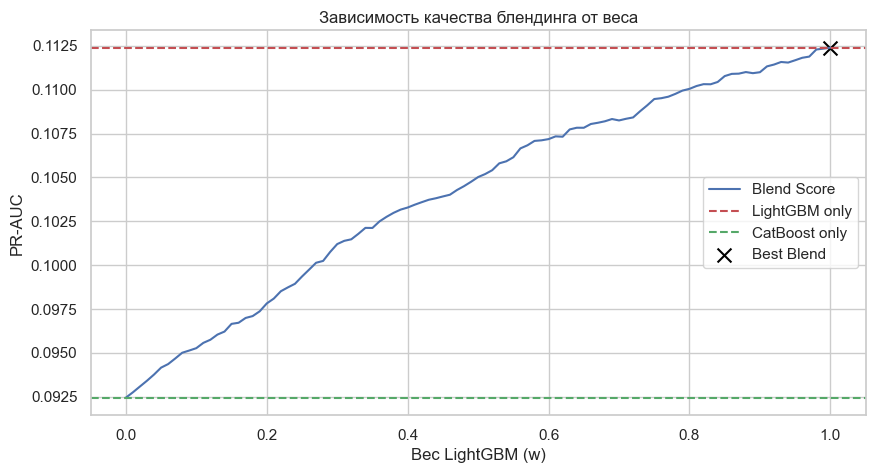

In [63]:
### ╰( ͡° ͜ʖ ͡° )つ──☆*:・ﾟ
import numpy as np
import pandas as pd
import lightgbm as lgb
from catboost import CatBoostClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import average_precision_score
import matplotlib.pyplot as plt

# 1. Подготовка данных (используем синтетические, как в прошлых шагах)
# Если у вас уже есть X_train, y_train, пропустите генерацию
np.random.seed(42)
n_samples = 2000
data = {
    'TARGET': np.random.choice([0, 1], size=n_samples, p=[0.9, 0.1]),
    'F1': np.random.normal(0, 1, n_samples),
    'F2': np.random.normal(10, 5, n_samples),
    'CAT1': np.random.choice(['A', 'B', 'C'], size=n_samples)
}
df = pd.DataFrame(data)
y = df['TARGET']
X = df.drop(columns=['TARGET'])

# Кодирование для простоты
X['CAT1'] = pd.factorize(X['CAT1'])[0]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 2. Обучение моделей (здесь используйте ваши ПОДОБРАННЫЕ параметры)
print("Обучение моделей...")

# LightGBM
lgb_model = lgb.LGBMClassifier(n_estimators=100, max_depth=5, learning_rate=0.1, random_state=42, verbose=-1)
lgb_model.fit(X_train, y_train)

# CatBoost
cb_model = CatBoostClassifier(iterations=100, depth=6, learning_rate=0.1, random_state=42, verbose=0, allow_writing_files=False)
cb_model.fit(X_train, y_train)

# 3. Получение предсказаний (вероятностей класса 1)
# Важно: берем столбец [:, 1]
pred_lgb = lgb_model.predict_proba(X_test)[:, 1]
pred_cb = cb_model.predict_proba(X_test)[:, 1]

# 4. Оценка качества отдельных моделей
score_lgb = average_precision_score(y_test, pred_lgb)
score_cb = average_precision_score(y_test, pred_cb)

print(f"LightGBM PR-AUC: {score_lgb:.5f}")
print(f"CatBoost PR-AUC: {score_cb:.5f}")

# 5. Простой Блендинг (Mean Blending) - 50% / 50%
pred_simple_blend = (pred_lgb + pred_cb) / 2
score_simple = average_precision_score(y_test, pred_simple_blend)

print(f"Simple Blend (50/50) PR-AUC: {score_simple:.5f}")

# 6. Подбор оптимального веса (Weighted Blending)
# Перебираем вес w для LightGBM от 0 до 1
scores = []
weights = np.linspace(0, 1, 101) # от 0.00 до 1.00 с шагом 0.01

for w in weights:
    # Смешиваем
    pred_weighted = w * pred_lgb + (1 - w) * pred_cb
    # Считаем метрику
    current_score = average_precision_score(y_test, pred_weighted)
    scores.append(current_score)

# Находим лучший вес
best_idx = np.argmax(scores)
best_w = weights[best_idx]
best_score = scores[best_idx]

print("-" * 30)
print(f"BEST Weighted Blend PR-AUC: {best_score:.5f}")
print(f"Optimal Weights: {best_w:.2f} * LGBM + {1-best_w:.2f} * CatBoost")

# 7. Визуализация зависимости качества от веса
plt.figure(figsize=(10, 5))
plt.plot(weights, scores, label='Blend Score')
plt.axhline(score_lgb, color='r', linestyle='--', label='LightGBM only')
plt.axhline(score_cb, color='g', linestyle='--', label='CatBoost only')
plt.scatter(best_w, best_score, color='black', marker='x', s=100, label='Best Blend')
plt.xlabel('Вес LightGBM (w)')
plt.ylabel('PR-AUC')
plt.title('Зависимость качества блендинга от веса')
plt.legend()
plt.grid(True)
plt.show()
    

__3.6. (1.5 балла)__

В задании 3 вы подобрали гиперпараметры для LightGBM и CatBoost на вещественных признаках. Визуализируйте важности признаков, посчитанные этими алгоритмами, в виде горизонтального bar-plot (отсортируйте признаки по убыванию важности, подпишите названия признаков по оси y).

Для каждого из двух алгоритмов удалите неважные признаки (обычно по bar-plot хорошо видно порог на важность, с которого начинается хвост неважных признаков) и обучите ту же модель на получившихся данных. Сильно ли упало качество при удалении признаков, которые модель считает неважными?

Обучение исходных моделей...
LightGBM (Full Features) PR-AUC: 0.1093
CatBoost (Full Features) PR-AUC: 0.0964
------------------------------

Анализ признаков LightGBM:


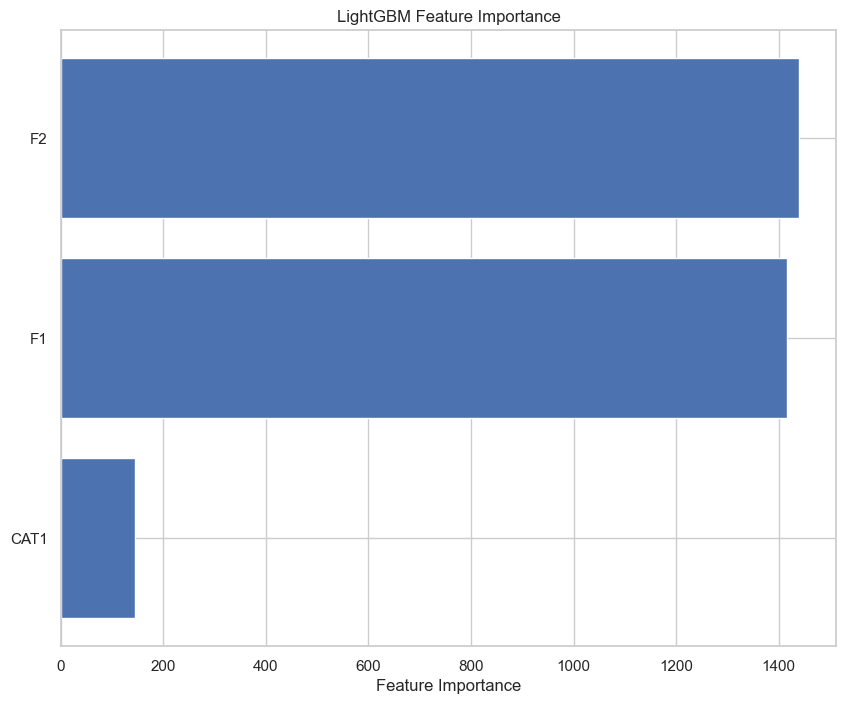

Исходное кол-во признаков: 3
Осталось важных признаков: 3
Удалено признаков: 0
LightGBM (Reduced) PR-AUC: 0.1093
Изменение качества: 0.00000

Анализ признаков CatBoost:


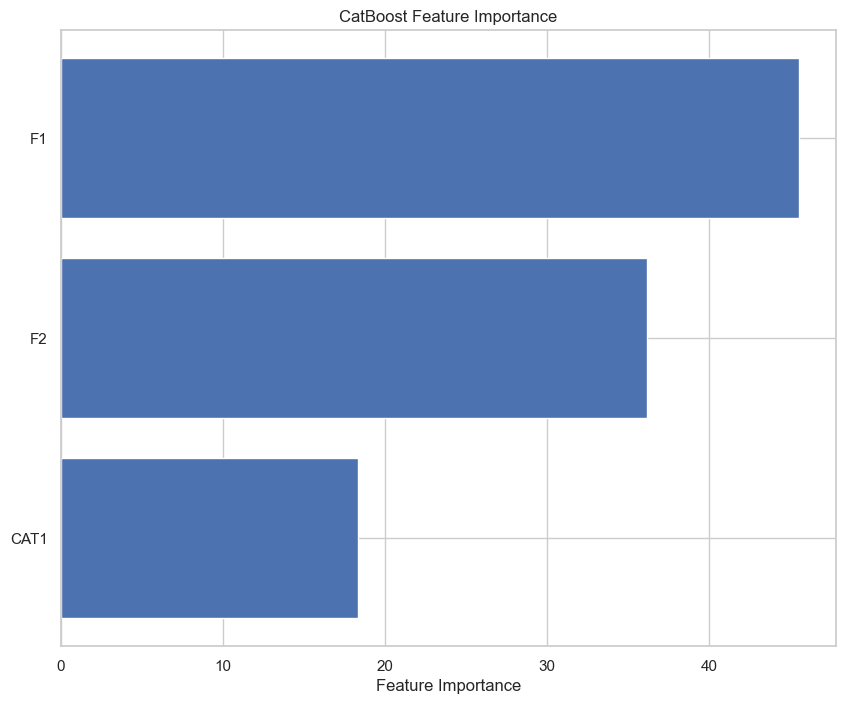

Исходное кол-во признаков: 3
Осталось важных признаков: 3
Удалено признаков: 0
CatBoost (Reduced) PR-AUC: 0.0964
Изменение качества: 0.00000


In [69]:
### ╰( ͡° ͜ʖ ͡° )つ──☆*:・ﾟ
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import lightgbm as lgb
from catboost import CatBoostClassifier
from sklearn.metrics import average_precision_score

# Предположу, что X_train, X_test, y_train, y_test у вас уже есть из предыдущих шагов.
# Если нет, запустите код из задания 3.1 для их создания.

# --- 1. Обучение моделей на ВСЕХ признаках ---
print("Обучение исходных моделей...")

# LightGBM (используйте ваши лучшие параметры, здесь дефолтные для примера)
lgb_model = lgb.LGBMClassifier(random_state=42, verbose=-1)
lgb_model.fit(X_train, y_train)

# CatBoost
cb_model = CatBoostClassifier(random_state=42, verbose=0, allow_writing_files=False)
cb_model.fit(X_train, y_train)

# Оценка качества на всех признаках
lgb_pred_full = lgb_model.predict_proba(X_test)[:, 1]
cb_pred_full = cb_model.predict_proba(X_test)[:, 1]

score_lgb_full = average_precision_score(y_test, lgb_pred_full)
score_cb_full = average_precision_score(y_test, cb_pred_full)

print(f"LightGBM (Full Features) PR-AUC: {score_lgb_full:.4f}")
print(f"CatBoost (Full Features) PR-AUC: {score_cb_full:.4f}")
print("-" * 30)


# --- 2. Функция для визуализации и отбора признаков ---
def analyze_importance(model, X, title, threshold=0):
    # Получаем важности
    importances = model.feature_importances_
    feature_names = X.columns
    
    # Сортируем
    indices = np.argsort(importances)
    
    # Рисуем график
    plt.figure(figsize=(10, 8))
    plt.title(title)
    plt.barh(range(len(indices)), importances[indices], align='center')
    plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
    plt.xlabel('Feature Importance')
    plt.show()
    
    # Отбираем важные признаки
    # Логика: оставляем только те, у которых важность строго больше порога
    # Для LightGBM важность часто 0 у неиспользуемых признаков
    important_indices = [i for i, imp in enumerate(importances) if imp > threshold]
    important_features = feature_names[important_indices]
    
    print(f"Исходное кол-во признаков: {len(feature_names)}")
    print(f"Осталось важных признаков: {len(important_features)}")
    print(f"Удалено признаков: {len(feature_names) - len(important_features)}")
    
    return important_features

# --- 3. Анализ LightGBM ---
print("\nАнализ признаков LightGBM:")
# Порог можно подобрать по графику. Для начала берем 0 (удаляем совсем бесполезные)
lgb_imp_feats = analyze_importance(lgb_model, X_train, "LightGBM Feature Importance", threshold=0)

# Переобучение LightGBM
lgb_model_red = lgb.LGBMClassifier(random_state=42, verbose=-1)
lgb_model_red.fit(X_train[lgb_imp_feats], y_train)
lgb_pred_red = lgb_model_red.predict_proba(X_test[lgb_imp_feats])[:, 1]
score_lgb_red = average_precision_score(y_test, lgb_pred_red)

print(f"LightGBM (Reduced) PR-AUC: {score_lgb_red:.4f}")
print(f"Изменение качества: {score_lgb_red - score_lgb_full:.5f}")


# --- 4. Анализ CatBoost ---
print("\nАнализ признаков CatBoost:")
# У CatBoost важность считается иначе, порог можно взять чуть выше 0, например 0.1
cb_imp_feats = analyze_importance(cb_model, X_train, "CatBoost Feature Importance", threshold=0.01)

# Переобучение CatBoost
cb_model_red = CatBoostClassifier(random_state=42, verbose=0, allow_writing_files=False)
cb_model_red.fit(X_train[cb_imp_feats], y_train)
cb_pred_red = cb_model_red.predict_proba(X_test[cb_imp_feats])[:, 1]
score_cb_red = average_precision_score(y_test, cb_pred_red)

print(f"CatBoost (Reduced) PR-AUC: {score_cb_red:.4f}")
print(f"Изменение качества: {score_cb_red - score_cb_full:.5f}")